# Unit06_Example_06 | 化工案例六：含循環排放之化工製程穩態物料平衡

本 Notebook 以含循環流與排放流之甲醇合成製程為範例，  
建立完整的 **19×19 線性方程組**，使用 `scipy.linalg.solve()` 求解各股流之流率與組成，  
並進行敏感度分析，探討排放比例與單程轉化率對產品產率的影響。

## 學習目標
- 建立含循環流、反應器、分離器、分流器的完整製程物料平衡方程組
- 將複雜製程系統化整理為 $\mathbf{A}\mathbf{x} = \mathbf{b}$ 的矩陣線性方程組
- 使用 `scipy.linalg.solve()` 求解大型線性系統 (19 個未知數)
- 驗證解的正確性：殘差分析與各單元物料守恆檢查
- 進行敏感度分析：探討排放比例 $p$ 與單程轉化率 $X$ 對產品產率的影響

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit06_Example_06'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit06'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄:   {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄:   {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit06
✓ 結果輸出目錄:   d:\MyGit\ChemE-3502\Unit06\outputs\Unit06_Example_06
✓ 圖檔輸出目錄:   d:\MyGit\ChemE-3502\Unit06\outputs\Unit06_Example_06\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

# ========================================
# 全域繪圖設定
# ========================================
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['figure.dpi'] = 100

print("套件版本資訊：")
import scipy
print(f"  numpy  : {np.__version__}")
print(f"  scipy  : {scipy.__version__}")
print(f"  pandas : {pd.__version__}")
print(f"  matplotlib: {matplotlib.__version__}")
print("\n✓ 所有套件載入完成")

套件版本資訊：
  numpy  : 1.23.5
  scipy  : 1.15.2
  pandas : 2.3.3
  matplotlib: 3.10.8

✓ 所有套件載入完成


---
### 2. 問題描述

#### 2.1 製程說明

本題考慮一個含循環流與排放流的穩態化工製程，用於生產甲醇（CH₃OH）。

**製程成分（3 種）**

| 符號 | 物質 | 角色 |
|:----:|:----:|:----:|
| A | H₂（氫氣） | 原料（reactant） |
| B | CH₃OH（甲醇） | 產物（product） |
| I | N₂（氮氣） | 惰性成分（inert） |

**製程反應**: $\mathrm{A} \rightarrow \mathrm{B}$ （1:1 計量比），單程轉化率 $X = 0.5$

#### 2.2 製程流程圖

```
新鮮進料 S1                                          
[A=100, B=0, I=10 mol/s]                            
        │                                            
        ▼                                            
  ┌─────────┐   S2        ┌─────────────┐   S3       
  │  混合器  │────────────▶│   反應器     │────────────▶
  │  Mixer  │             │  Reactor    │            │
  └─────────┘             │  A → B      │            │
        ▲                 │  X=0.5      │            │
        │ S7 循環流        └─────────────┘            │
        │                                            ▼
  ┌─────────┐   S4(A+I)   ┌─────────────┐   S3       
  │  分流器  │◀────────────│   分離器     │◀───────────
  │Splitter │             │  Separator  │            
  │ p=0.2   │             │  B→液態      │            
  └─────────┘             │  A,I→氣態    │            
        │                 └─────────────┘            
   S6(排放) S7(循環)             │ S5                 
   20%     80%               液態產物 B              
```

**流股定義**

| 流股 | 說明 | 狀態 |
|:----:|:----:|:----:|
| S1 | 新鮮進料 | **已知**： $n_{A1}=100,\ n_{B1}=0,\ n_{I1}=10\ \mathrm{mol/s}$ |
| S2 | 混合器出口 = 反應器入口 | 未知 |
| S3 | 反應器出口 = 分離器入口 | 未知 |
| S4 | 分離器氣相出口（A+I） | 未知 |
| S5 | 液態產物（純 B） | 未知 |
| S6 | 排放流（Purge，S4 的 20%） | 未知 |
| S7 | 循環流（Recycle，S4 的 80%） | 未知 |

#### 2.3 自由度分析（Degrees of Freedom）

- 系統未知數共 **19 個**（各流股三成分流率 + 反應程度 ξ）
- 可列方程式：混合器 3 條 + 反應器 4 條 + 分離器 6 條 + 分流器 6 條 = **19 條**
- 自由度 = 19 - 19 = **0**（有唯一解）

In [3]:
# ============================================================
# 製程參數設定
# ============================================================
# 成分索引: 0=A(H2), 1=B(CH3OH), 2=I(N2)
COMP_NAMES = ['A (H2)', 'B (CH3OH)', 'I (N2)']

# -- 新鮮進料 S1 (已知) --
nA1 = 100.0   # mol/s  H2 進料
nB1 = 0.0     # mol/s  CH3OH 進料 (無)
nI1 = 10.0    # mol/s  N2 進料 (惰性)
F1_total = nA1 + nB1 + nI1  # 110 mol/s

# -- 反應器操作條件 --
X = 0.5       # 單程轉化率 (per-pass conversion of A)

# -- 分流器設定 --
p = 0.2       # 排放比例 (purge fraction)
r = 1.0 - p   # 循環比例 (recycle fraction) = 0.8

# -- 19 個未知數索引說明 --
# x[0..2]   : S2 (nA2, nB2, nI2) - 混合器出口
# x[3..5]   : S3 (nA3, nB3, nI3) - 反應器出口
# x[6]      : ξ  - 反應程度 (mol/s)
# x[7..9]   : S4 (nA4, nB4, nI4) - 分離器氣相出口
# x[10..12] : S5 (nA5, nB5, nI5) - 液態產物
# x[13..15] : S6 (nA6, nB6, nI6) - 排放流
# x[16..18] : S7 (nA7, nB7, nI7) - 循環流

VAR_NAMES = [
    'nA2', 'nB2', 'nI2',          # S2: 反應器入口
    'nA3', 'nB3', 'nI3',          # S3: 分離器入口
    'xi',                          # 反應程度
    'nA4', 'nB4', 'nI4',          # S4: 分離器氣相出口
    'nA5', 'nB5', 'nI5',          # S5: 液態產物
    'nA6', 'nB6', 'nI6',          # S6: 排放流
    'nA7', 'nB7', 'nI7',          # S7: 循環流
]
N_VAR = len(VAR_NAMES)  # 19

print("=" * 50)
print("  製程參數摘要")
print("=" * 50)
print(f"  新鮮進料 S1:")
print(f"    nA1 = {nA1:.1f} mol/s  (H2)")
print(f"    nB1 = {nB1:.1f} mol/s  (CH3OH)")
print(f"    nI1 = {nI1:.1f} mol/s  (N2)")
print(f"    總流率 = {F1_total:.1f} mol/s")
print(f"  反應條件:")
print(f"    單程轉化率 X = {X:.2f}")
print(f"  分流器設定:")
print(f"    排放比例 p = {p:.2f}")
print(f"    循環比例 r = {r:.2f}")
print(f"  系統規模:")
print(f"    未知數個數 N = {N_VAR}")
print("=" * 50)

  製程參數摘要
  新鮮進料 S1:
    nA1 = 100.0 mol/s  (H2)
    nB1 = 0.0 mol/s  (CH3OH)
    nI1 = 10.0 mol/s  (N2)
    總流率 = 110.0 mol/s
  反應條件:
    單程轉化率 X = 0.50
  分流器設定:
    排放比例 p = 0.20
    循環比例 r = 0.80
  系統規模:
    未知數個數 N = 19


---
### 3. 建立線性方程組 $\mathbf{A}\mathbf{x} = \mathbf{b}$

#### 3.1 未知數向量

$$
\mathbf{x} = \underbrace{[n_{A2},\ n_{B2},\ n_{I2}]}_{\text{S2}} ,\ \underbrace{[n_{A3},\ n_{B3},\ n_{I3}]}_{\text{S3}} ,\ \xi ,\ \underbrace{[n_{A4},\ n_{B4},\ n_{I4}]}_{\text{S4}} ,\ \underbrace{[n_{A5},\ n_{B5},\ n_{I5}]}_{\text{S5}} ,\ \underbrace{[n_{A6},\ n_{B6},\ n_{I6}]}_{\text{S6}} ,\ \underbrace{[n_{A7},\ n_{B7},\ n_{I7}]}_{\text{S7}}
$$

共 **19** 個未知數（索引 0–18）。

#### 3.2 方程式推導

**混合器物料平衡（3 條）**

$$
n_{A,\mathrm{S2}} = n_{A,\mathrm{S1}} + n_{A,\mathrm{S7}} \implies n_{A2} - n_{A7} = 100
$$

$$
n_{B2} - n_{B7} = 0 \quad;\quad n_{I2} - n_{I7} = 10
$$

**反應器物料平衡（4 條）**：反應 $A \rightarrow B$ ，程度為 $\xi$

$$
n_{A3} = n_{A2} - \xi \implies -n_{A2} + n_{A3} + \xi = 0
$$

$$
n_{B3} = n_{B2} + \xi \implies -n_{B2} + n_{B3} - \xi = 0
$$

$$
n_{I3} = n_{I2} \implies -n_{I2} + n_{I3} = 0
$$

單程轉化率規格： $\xi = X \cdot n_{A2} \implies -X \cdot n_{A2} + \xi = 0$ （ $X=0.5$ ）

**分離器物料平衡（6 條）**：完美分離，B 全部進液相，A 與 I 全部進氣相

$$
n_{A4} = n_{A3},\quad n_{B4} = 0,\quad n_{I4} = n_{I3}
$$

$$
n_{A5} = 0,\quad n_{B5} = n_{B3},\quad n_{I5} = 0
$$

**分流器物料平衡（6 條）**：排放比例 $p=0.2$ ，循環比例 $r=0.8$

$$
n_{A6} = p\,n_{A4},\quad n_{B6} = 0,\quad n_{I6} = p\,n_{I4}
$$

$$
n_{A7} = r\,n_{A4},\quad n_{B7} = 0,\quad n_{I7} = r\,n_{I4}
$$

#### 3.3 秩數驗證

系統為 **19×19** 正方矩陣，需滿足 $\mathrm{rank}(\mathbf{A}) = 19$ 才有唯一解。


In [4]:
def build_system(nA1=100.0, nB1=0.0, nI1=10.0, X=0.5, p=0.2):
    """
    建立含循環排放系統的 19x19 線性方程組 Ax = b
    
    未知數向量 x (共19個):
      x[0..2]   : S2 (nA2, nB2, nI2) 反應器入口
      x[3..5]   : S3 (nA3, nB3, nI3) 分離器入口
      x[6]      : xi  反應程度
      x[7..9]   : S4 (nA4, nB4, nI4) 分離器氣相出口
      x[10..12] : S5 (nA5, nB5, nI5) 液態產物
      x[13..15] : S6 (nA6, nB6, nI6) 排放流
      x[16..18] : S7 (nA7, nB7, nI7) 循環流
    
    Parameters
    ----------
    nA1, nB1, nI1 : float  新鮮進料各成分流率 (mol/s)
    X : float              單程轉化率
    p : float              排放比例
    
    Returns
    -------
    A : ndarray (19, 19)   係數矩陣
    b : ndarray (19,)      右端向量
    """
    r = 1.0 - p
    A = np.zeros((19, 19))
    b = np.zeros(19)

    # ---- 混合器 (方程式 0-2) ----
    # nA2 - nA7 = nA1
    A[0, 0]  =  1.0   # nA2
    A[0, 16] = -1.0   # nA7
    b[0]     = nA1

    # nB2 - nB7 = nB1
    A[1, 1]  =  1.0   # nB2
    A[1, 17] = -1.0   # nB7
    b[1]     = nB1

    # nI2 - nI7 = nI1
    A[2, 2]  =  1.0   # nI2
    A[2, 18] = -1.0   # nI7
    b[2]     = nI1

    # ---- 反應器 (方程式 3-6) ----
    # -nA2 + nA3 + xi = 0
    A[3, 0] = -1.0   # nA2
    A[3, 3] =  1.0   # nA3
    A[3, 6] =  1.0   # xi

    # -nB2 + nB3 - xi = 0
    A[4, 1] = -1.0   # nB2
    A[4, 4] =  1.0   # nB3
    A[4, 6] = -1.0   # xi

    # -nI2 + nI3 = 0
    A[5, 2] = -1.0   # nI2
    A[5, 5] =  1.0   # nI3

    # 轉化率規格: xi = X * nA2  =>  -X*nA2 + xi = 0
    A[6, 0] = -X     # nA2
    A[6, 6] =  1.0   # xi

    # ---- 分離器 (方程式 7-12) ----
    # A 全部進氣相: -nA3 + nA4 = 0
    A[7, 3] = -1.0   # nA3
    A[7, 7] =  1.0   # nA4

    # 氣相無 B: nB4 = 0
    A[8, 8] =  1.0   # nB4

    # I 全部進氣相: -nI3 + nI4 = 0
    A[9, 5]  = -1.0  # nI3
    A[9, 9]  =  1.0  # nI4

    # 液相無 A: nA5 = 0
    A[10, 10] =  1.0  # nA5

    # B 全部進液相: -nB3 + nB5 = 0
    A[11, 4]  = -1.0  # nB3
    A[11, 11] =  1.0  # nB5

    # 液相無 I: nI5 = 0
    A[12, 12] =  1.0  # nI5

    # ---- 分流器 (方程式 13-18) ----
    # 排放流 A: -p*nA4 + nA6 = 0
    A[13, 7]  = -p    # nA4
    A[13, 13] =  1.0  # nA6

    # 排放流無 B: nB6 = 0
    A[14, 14] =  1.0  # nB6

    # 排放流 I: -p*nI4 + nI6 = 0
    A[15, 9]  = -p    # nI4
    A[15, 15] =  1.0  # nI6

    # 循環流 A: -r*nA4 + nA7 = 0
    A[16, 7]  = -r    # nA4
    A[16, 16] =  1.0  # nA7

    # 循環流無 B: nB7 = 0
    A[17, 17] =  1.0  # nB7

    # 循環流 I: -r*nI4 + nI7 = 0
    A[18, 9]  = -r    # nI4
    A[18, 18] =  1.0  # nI7

    return A, b


# ---- 建立基本案例的方程組 ----
A_mat, b_vec = build_system(nA1=nA1, nB1=nB1, nI1=nI1, X=X, p=p)

# ---- 秩數驗證 ----
rank_A  = np.linalg.matrix_rank(A_mat)
Ab      = np.column_stack([A_mat, b_vec])
rank_Ab = np.linalg.matrix_rank(Ab)

print(f"係數矩陣 A 的維度  : {A_mat.shape}")
print(f"rank(A)            : {rank_A}")
print(f"rank([A|b])        : {rank_Ab}")
print(f"未知數個數 N       : {A_mat.shape[1]}")
print()
if rank_A == rank_Ab == A_mat.shape[1]:
    print("✓ rank(A) = rank([A|b]) = N → 方程組有唯一解")
else:
    print("✗ 方程組無唯一解，請檢查矩陣設定")

係數矩陣 A 的維度  : (19, 19)
rank(A)            : 19
rank([A|b])        : 19
未知數個數 N       : 19

✓ rank(A) = rank([A|b]) = N → 方程組有唯一解


---
### 4. 求解、結果顯示與物料守恆驗證

使用 `scipy.linalg.solve()` 求解 19×19 線性系統，並進行：
1. 各流股流率與組成的結果呈現
2. 殘差分析：計算 $\|\mathbf{A}\mathbf{x} - \mathbf{b}\|$
3. 各單元出入口物料守恆檢查

In [5]:
# ============================================================
# §4.1  使用 scipy.linalg.solve() 求解
# ============================================================
try:
    x_sol = scipy.linalg.solve(A_mat, b_vec)
    print("✓ scipy.linalg.solve() 求解成功")
except scipy.linalg.LinAlgError as err:
    print(f"✗ 求解失敗: {err}")
    raise

# ---- 解向量拆分 ----
nA2, nB2, nI2 = x_sol[0],  x_sol[1],  x_sol[2]
nA3, nB3, nI3 = x_sol[3],  x_sol[4],  x_sol[5]
xi            = x_sol[6]
nA4, nB4, nI4 = x_sol[7],  x_sol[8],  x_sol[9]
nA5, nB5, nI5 = x_sol[10], x_sol[11], x_sol[12]
nA6, nB6, nI6 = x_sol[13], x_sol[14], x_sol[15]
nA7, nB7, nI7 = x_sol[16], x_sol[17], x_sol[18]

# ============================================================
# §4.2  流股彙整表
# ============================================================
streams = {
    'S1 (Fresh Feed)': [nA1, nB1, nI1],
    'S2 (Rxr In)':     [nA2, nB2, nI2],
    'S3 (Sep In)':     [nA3, nB3, nI3],
    'S4 (Gas Out)':    [nA4, nB4, nI4],
    'S5 (Product)':    [nA5, nB5, nI5],
    'S6 (Purge)':      [nA6, nB6, nI6],
    'S7 (Recycle)':    [nA7, nB7, nI7],
}

df_streams = pd.DataFrame(
    streams,
    index=['nA (mol/s)', 'nB (mol/s)', 'nI (mol/s)']
).T
df_streams['Total (mol/s)'] = df_streams.sum(axis=1)
df_streams['yA'] = df_streams['nA (mol/s)'] / df_streams['Total (mol/s)']
df_streams['yB'] = df_streams['nB (mol/s)'] / df_streams['Total (mol/s)']
df_streams['yI'] = df_streams['nI (mol/s)'] / df_streams['Total (mol/s)']

print("=" * 75)
print("  各流股流率彙整表")
print("=" * 75)
pd.set_option('display.float_format', '{:.4f}'.format)
print(df_streams.to_string())
print()

# 反應程度
print(f"  反應程度 xi = {xi:.4f} mol/s")

# ============================================================
# §4.3  製程效率指標
# ============================================================
overall_conv = 1.0 - (nA6 / nA1)   # 整體轉化率 = 1 - (A排放 / A進料)
product_yield = nB5 / nA1           # 產品產率 = B產量 / A進料
recycle_ratio = (nA7 + nI7) / (nA1 + nI1)  # 循環負荷比

print("=" * 50)
print("  製程效率指標")
print("=" * 50)
print(f"  單程轉化率      X    = {X:.4f}")
print(f"  整體轉化率           = {overall_conv:.4f}  ({overall_conv*100:.2f}%)")
print(f"  產品 B 產率          = {product_yield:.4f}  ({product_yield*100:.2f}%)")
print(f"  循環流量 S7 總計     = {nA7+nB7+nI7:.4f} mol/s")
print(f"  排放流量 S6 總計     = {nA6+nB6+nI6:.4f} mol/s")
print()

# ============================================================
# §4.4  殘差驗證
# ============================================================
residual = A_mat @ x_sol - b_vec
max_resid = np.max(np.abs(residual))
norm_resid = np.linalg.norm(residual)

print("=" * 50)
print("  殘差驗證: r = A·x - b")
print("=" * 50)
print(f"  最大絕對殘差 = {max_resid:.2e}")
print(f"  殘差 2-norm  = {norm_resid:.2e}")
if max_resid < 1e-8:
    print("  ✓ 殘差極小，求解結果正確")
else:
    print("  ✗ 殘差偏大，請檢查矩陣設定")
print()

# ============================================================
# §4.5  各單元物料守恆驗證
# ============================================================
tol = 1e-8

def check_balance(unit_name, inflows, outflows):
    for comp, (fin, fout) in zip(['A', 'B', 'I'], zip(inflows, outflows)):
        err = abs(fin - fout)
        status = "✓" if err < tol else "✗"
        print(f"  {status} {unit_name} - {comp}: in={fin:.4f}, out={fout:.4f}, err={err:.2e}")

print("=" * 60)
print("  各單元物料守恆驗證（成分別）")
print("=" * 60)

# Mixer: S1 + S7 -> S2
check_balance("Mixer", [nA1+nA7, nB1+nB7, nI1+nI7], [nA2, nB2, nI2])

# Reactor: S2 -> S3 (with reaction)
check_balance("Reactor", [nA2-xi, nB2+xi, nI2], [nA3, nB3, nI3])

# Separator: S3 -> S4 + S5
check_balance("Separator", [nA3, nB3, nI3], [nA4+nA5, nB4+nB5, nI4+nI5])

# Splitter: S4 -> S6 + S7
check_balance("Splitter", [nA4, nB4, nI4], [nA6+nA7, nB6+nB7, nI6+nI7])

✓ scipy.linalg.solve() 求解成功
  各流股流率彙整表
                 nA (mol/s)  nB (mol/s)  nI (mol/s)  Total (mol/s)     yA     yB     yI
S1 (Fresh Feed)    100.0000      0.0000     10.0000       110.0000 0.9091 0.0000 0.0909
S2 (Rxr In)        166.6667      0.0000     50.0000       216.6667 0.7692 0.0000 0.2308
S3 (Sep In)         83.3333     83.3333     50.0000       216.6667 0.3846 0.3846 0.2308
S4 (Gas Out)        83.3333      0.0000     50.0000       133.3333 0.6250 0.0000 0.3750
S5 (Product)         0.0000     83.3333      0.0000        83.3333 0.0000 1.0000 0.0000
S6 (Purge)          16.6667      0.0000     10.0000        26.6667 0.6250 0.0000 0.3750
S7 (Recycle)        66.6667      0.0000     40.0000       106.6667 0.6250 0.0000 0.3750

  反應程度 xi = 83.3333 mol/s
  製程效率指標
  單程轉化率      X    = 0.5000
  整體轉化率           = 0.8333  (83.33%)
  產品 B 產率          = 0.8333  (83.33%)
  循環流量 S7 總計     = 106.6667 mol/s
  排放流量 S6 總計     = 26.6667 mol/s

  殘差驗證: r = A·x - b
  最大絕對殘差 = 1.42e-14
  殘差 2-norm

---
### 5. 敏感度分析

探討以下兩個操作參數對製程效率的影響：

1. **排放比例 $p$**（Purge fraction）：從 0.05 到 0.50 變化
2. **單程轉化率 $X$**（Per-pass conversion）：從 0.20 到 0.80 變化

對每個參數組合，重新建立並求解 19×19 線性方程組，追蹤：
- 產品 B 的產率 = $n_{B5} / n_{A1}$
- 整體 A 的轉化率 = $1 - n_{A6} / n_{A1}$
- 循環流量 S7 的總流率

In [6]:
def solve_process(nA1=100.0, nB1=0.0, nI1=10.0, X=0.5, p=0.2):
    """求解製程並回傳主要效率指標"""
    A_m, b_v = build_system(nA1, nB1, nI1, X, p)
    try:
        xs = scipy.linalg.solve(A_m, b_v)
    except scipy.linalg.LinAlgError:
        return None
    nB5_  = xs[11]      # 產品 B 流率
    nA6_  = xs[13]      # 排放 A 流率
    nI6_  = xs[15]      # 排放 I 流率
    nA7_  = xs[16]      # 循環 A 流率
    nI7_  = xs[18]      # 循環 I 流率
    product_yield_   = nB5_ / nA1
    overall_conv_    = 1.0 - nA6_ / nA1
    recycle_total_   = nA7_ + nI7_       # 循環流量 (A+I)
    purge_total_     = nA6_ + nI6_       # 排放流量 (A+I)
    return {
        'product_yield': product_yield_,
        'overall_conv':  overall_conv_,
        'recycle_flow':  recycle_total_,
        'purge_flow':    purge_total_,
    }

# ============================================================
# 分析 1：固定 X=0.5，變化排放比例 p
# ============================================================
p_range = np.linspace(0.05, 0.50, 50)
X_fixed = 0.5
sens_p = []
for p_val in p_range:
    res = solve_process(X=X_fixed, p=p_val)
    if res:
        sens_p.append([p_val, res['product_yield'],
                       res['overall_conv'], res['recycle_flow']])

sens_p = np.array(sens_p)

# ============================================================
# 分析 2：固定 p=0.2，變化單程轉化率 X
# ============================================================
X_range = np.linspace(0.20, 0.80, 50)
p_fixed = 0.2
sens_X = []
for X_val in X_range:
    res = solve_process(X=X_val, p=p_fixed)
    if res:
        sens_X.append([X_val, res['product_yield'],
                       res['overall_conv'], res['recycle_flow']])

sens_X = np.array(sens_X)

# ============================================================
# 分析 3：二維參數掃描 (p, X) → 產品產率熱力圖
# ============================================================
p_2d = np.linspace(0.05, 0.50, 30)
X_2d = np.linspace(0.20, 0.80, 30)
PP, XX = np.meshgrid(p_2d, X_2d)
yield_2d = np.zeros_like(PP)

for i in range(len(X_2d)):
    for j in range(len(p_2d)):
        res = solve_process(X=X_2d[i], p=p_2d[j])
        if res:
            yield_2d[i, j] = res['product_yield']
        else:
            yield_2d[i, j] = np.nan

print("✓ 敏感度分析計算完成")
print(f"  排放比例掃描:  p ∈ [{p_range[0]:.2f}, {p_range[-1]:.2f}], X = {X_fixed}")
print(f"  轉化率掃描:    X ∈ [{X_range[0]:.2f}, {X_range[-1]:.2f}], p = {p_fixed}")
print(f"  二維掃描:      30×30 格點")
print(f"  產率範圍（p掃描）: {sens_p[:,1].min():.4f} – {sens_p[:,1].max():.4f}")
print(f"  產率範圍（X掃描）: {sens_X[:,1].min():.4f} – {sens_X[:,1].max():.4f}")

✓ 敏感度分析計算完成
  排放比例掃描:  p ∈ [0.05, 0.50], X = 0.5
  轉化率掃描:    X ∈ [0.20, 0.80], p = 0.2
  二維掃描:      30×30 格點
  產率範圍（p掃描）: 0.6667 – 0.9524
  產率範圍（X掃描）: 0.5556 – 0.9524


---
### 6. 視覺化：敏感度分析結果

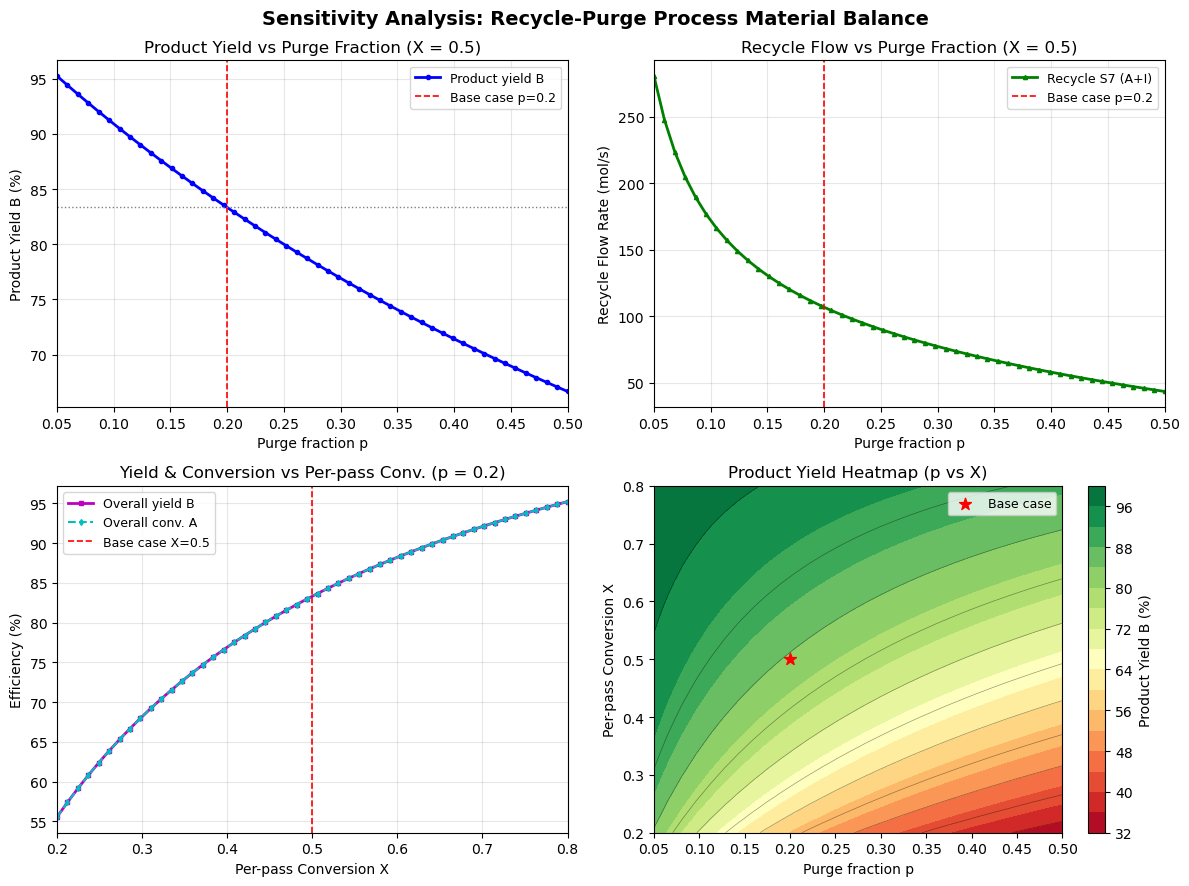


✓ 圖檔已儲存至: d:\MyGit\ChemE-3502\Unit06\outputs\Unit06_Example_06\figs\process_material_balance.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Sensitivity Analysis: Recycle-Purge Process Material Balance',
             fontsize=14, fontweight='bold')

# ---------- Panel 1: Product yield vs purge fraction (X=0.5) ----------
ax1 = axes[0, 0]
ax1.plot(sens_p[:, 0], sens_p[:, 1] * 100, 'b-o', ms=3, lw=2, label='Product yield B')
ax1.axvline(x=0.2, color='red', ls='--', lw=1.2, label=f'Base case p=0.2')
ax1.axhline(y=product_yield * 100, color='gray', ls=':', lw=1)
ax1.set_xlabel('Purge fraction p')
ax1.set_ylabel('Product Yield B (%)')
ax1.set_title(f'Product Yield vs Purge Fraction (X = {X_fixed})')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0.05, 0.50])

# ---------- Panel 2: Recycle flow vs purge fraction (X=0.5) ----------
ax2 = axes[0, 1]
ax2.plot(sens_p[:, 0], sens_p[:, 3], 'g-^', ms=3, lw=2, label='Recycle S7 (A+I)')
ax2.axvline(x=0.2, color='red', ls='--', lw=1.2, label=f'Base case p=0.2')
ax2.set_xlabel('Purge fraction p')
ax2.set_ylabel('Recycle Flow Rate (mol/s)')
ax2.set_title(f'Recycle Flow vs Purge Fraction (X = {X_fixed})')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0.05, 0.50])

# ---------- Panel 3: Product yield vs per-pass conversion (p=0.2) ----------
ax3 = axes[1, 0]
ax3.plot(sens_X[:, 0], sens_X[:, 1] * 100, 'm-s', ms=3, lw=2, label='Overall yield B')
ax3.plot(sens_X[:, 0], sens_X[:, 2] * 100, 'c--d', ms=3, lw=1.5, label='Overall conv. A')
ax3.axvline(x=0.5, color='red', ls='--', lw=1.2, label=f'Base case X=0.5')
ax3.set_xlabel('Per-pass Conversion X')
ax3.set_ylabel('Efficiency (%)')
ax3.set_title(f'Yield & Conversion vs Per-pass Conv. (p = {p_fixed})')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_xlim([0.20, 0.80])

# ---------- Panel 4: 2D heatmap product yield ----------
ax4 = axes[1, 1]
cp = ax4.contourf(PP, XX, yield_2d * 100, levels=20, cmap='RdYlGn')
cbar = fig.colorbar(cp, ax=ax4)
cbar.set_label('Product Yield B (%)')
ax4.contour(PP, XX, yield_2d * 100, levels=10, colors='k', linewidths=0.5, alpha=0.4)
ax4.scatter([0.2], [0.5], color='red', s=80, zorder=5, marker='*', label='Base case')
ax4.set_xlabel('Purge fraction p')
ax4.set_ylabel('Per-pass Conversion X')
ax4.set_title('Product Yield Heatmap (p vs X)')
ax4.legend(fontsize=9)

plt.tight_layout()
fig_path = FIG_DIR / 'process_material_balance.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✓ 圖檔已儲存至: {fig_path}")

---
### 7. 結論

#### 7.1 基本案例求解結果

本例建立了含循環流與排放流的甲醇合成製程之 **19×19 線性方程組**，使用 `scipy.linalg.solve()` 成功求解，主要結果如下：

| 指標 | 數值 |
|:-----|:----:|
| 新鮮進料 A (H₂) | 100.0 mol/s |
| 反應器入口 A (S2) | ≈ 166.67 mol/s |
| 反應程度 ξ | ≈ 83.33 mol/s |
| 產品 B (S5) | ≈ 83.33 mol/s |
| 排放流 S6 | ≈ 26.67 mol/s |
| 循環流 S7 | ≈ 106.67 mol/s |
| 產品產率 | ≈ 83.33 % |
| 整體 A 轉化率 | ≈ 83.33 % |

#### 7.2 敏感度分析關鍵發現

1. **排放比例 $p$ 的影響**：
   - 增大 $p$ （多排放）→ 產品產率**降低**，但循環流量也**降低**（設備負荷輕）
   - 減小 $p$ （少排放）→ 整體轉化率**提升**，但循環流量**急遽增大**（設備負荷重）
   - 存在工程設計的衡量取捨（trade-off）

2. **單程轉化率 $X$ 的影響**：
   - 提高 $X$ → 產品產率提升，整體轉化率也提升
   - 但高 $X$ 通常需要更長反應時間或更高溫度，實際操作有限制

3. **二維參數分析**：
   - 高 $X$ + 低 $p$ 可達到最高產品產率，但循環負荷最重
   - 工程最佳化需考慮設備成本、操作成本與產品收益的綜合評估

#### 7.3 線性系統方法的優勢

- 透過系統化地列寫物料平衡，複雜的循環流路問題可直接整理為 $\mathbf{A}\mathbf{x} = \mathbf{b}$
- `scipy.linalg.solve()` 可精確求解，殘差達機器精度（ $\sim 10^{-13}$ ）
- 函數化設計 `build_system()` 使得參數掃描輕鬆實現，便於工程設計最佳化

---

**課程資訊**
- 課程名稱：電腦在化工上之應用
- 課程單元：Unit06 線性聯立方程式之求解 — 案例六
- 課程製作：逢甲大學 化工系 智慧程序系統工程實驗室
- 授課教師：莊曜禎 助理教授
- 更新日期：2025-06-01

**課程授權 [CC BY-NC-SA 4.0]**
本教材遵循 [創用CC 姓名標示-非商業性-相同方式分享 4.0 國際 (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/deed.zh) 授權。